# Adaptation + Ablation (TODO.md §9)

Source-free adaptation on the frozen §4/§5 model: only the feature extractor
`g` (β) is updated on unlabeled target data; the linear head `h` (θ, MAP or
Laplace) is frozen throughout (`src/im_adapt.py`, paper's Sec. 3 / Fig. 3b).
Target labels are used **only** to score the arms below, never for
adaptation or model selection.

**IM loss** (`src/im_adapt.py`):

$$ \mathcal{L}_{\text{IM}} = (1-\gamma)\cdot\underbrace{\tfrac{1}{N}\sum_i w_i\, H[p(y|x_i)]}_{L_{\text{ent}}\text{ (weighted)}}
\;+\; \gamma\cdot\underbrace{\Big(-H\big[\tfrac{1}{N}\sum_i p(y|x_i)\big]\Big)}_{L_{\text{div}}} $$

Down-weighting ($w_i$) only ever touches $L_{\text{ent}}$, never $L_{\text{div}}$
(TODO.md §1). Six arms, same seeds/data/optimizer -- only $w_i$ and $\gamma$ change:

| arm | γ | weight $w_i$ |
|---|---|---|
| (a) no adaptation | -- | -- (frozen source model, baseline) |
| (b) entropy only | 0 | 1 (no diversity term at all -- expect collapse) |
| (c) IM, no weighting (SHOT-IM) | 0.5 | 1 |
| (d) IM + MAP predictive entropy weight | 0.5 | $\exp(-H^{\text{MAP}}_i)$ |
| (e) IM + Laplace predictive entropy weight (paper-faithful) | 0.5 | $\exp(-H^{\text{total}}_i)$ |
| (f) IM + standardized BALD epistemic weight (**deviation**) | 0.5 | $\exp(-z_i)$, $z_i$ = epistemic standardized vs. source |

τ = 0.4 (temperature, TODO.md §1) throughout. Arm (f) is an explicit
deviation from the paper -- it weights by the epistemic component alone
(standardized against the fixed source-val reference from §7/§8, never
per-batch) instead of total predictive entropy, and is expected to behave
less predictably as a result.

## Setup

In [9]:
import sys, copy, collections
from pathlib import Path

root_dir = Path().resolve().parent
sys.path.insert(0, str(root_dir))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.loader import load_har, LOCOMOTION_IDS
from src.subject_split import split_and_scale, centroid_distance_shift_proxy
from src.bayesian import FeatureClassifier, LastLayerLaplace
from src.har_train import subject_train_val_split, check_class_balance, train_source_model
from src.im_adapt import adapt_target
from src.calibration import reliability_bins, expected_calibration_error, nll

DATA_SEED = 42
K = 3
SEEDS = [0, 1, 2, 3, 4]
STEPS = 300
ADAPT_LR = 1e-2
GAMMA = 0.5
TEMPERATURE = 0.4  # TODO.md §1's fixed τ
M_ADAPT = 100      # MC samples used *during* adaptation (im_adapt.py default)
M_EVAL = 1000      # MC samples for the one-off source-val epistemic reference

ARMS = [
    dict(key="a", label="(a) no adaptation", weight_mode=None, gamma=None),
    dict(key="b", label="(b) entropy only", weight_mode="none", gamma=0.0),
    dict(key="c", label="(c) IM, no weighting (SHOT-IM)", weight_mode="none", gamma=GAMMA),
    dict(key="d", label="(d) IM + MAP entropy weight", weight_mode="map_entropy", gamma=GAMMA),
    dict(key="e", label="(e) IM + Laplace entropy weight (paper-faithful)", weight_mode="uncertainty", gamma=GAMMA),
    dict(key="f", label="(f) IM + standardized epistemic weight (deviation)", weight_mode="epistemic_standardized", gamma=GAMMA),
]
ARM_KEYS = [a["key"] for a in ARMS]
ARM_COLORS = {"a": "gray", "b": "tab:red", "c": "tab:orange", "d": "tab:green", "e": "tab:blue", "f": "tab:purple"}

print("Imports OK")

Imports OK


## 1. Data, split, shift proxy

Same source/target partition as §4-§8 (seed=42).

In [10]:
dataset_full = load_har("../data", merge_train_test=True)
dataset = dataset_full.filter_activities(LOCOMOTION_IDS)
split = split_and_scale(dataset, n_source=20, seed=DATA_SEED)
shift_proxy = centroid_distance_shift_proxy(dataset, split)

train_subjects, val_subjects = subject_train_val_split(split.source_subjects, val_fraction=0.2, seed=DATA_SEED)
train_mask = np.isin(split.subject_id_source, train_subjects)
val_mask = np.isin(split.subject_id_source, val_subjects)
label_map = {1: 0, 2: 1, 3: 2}

X_train = torch.tensor(split.X_source[train_mask], dtype=torch.float32)
X_val = torch.tensor(split.X_source[val_mask], dtype=torch.float32)
y_train = torch.tensor([label_map[y] for y in split.y_source[train_mask]], dtype=torch.long)
y_val = torch.tensor([label_map[y] for y in split.y_source[val_mask]], dtype=torch.long)

X_source_full = torch.tensor(split.X_source, dtype=torch.float32)
y_source_full = torch.tensor([label_map[y] for y in split.y_source], dtype=torch.long)

target_data = {}
for sid in sorted(split.target_subjects):
    ds_t = dataset.filter_subjects([sid])
    X_t = torch.tensor(split.scaler.transform(ds_t.X), dtype=torch.float32)
    y_t = torch.tensor([label_map[y] for y in ds_t.y], dtype=torch.long)
    target_data[int(sid)] = (X_t, y_t)

targets_sorted = sorted(target_data.keys())
HIGH_SHIFT = max(shift_proxy, key=shift_proxy.get)  # representative subject for trajectory plots

terciles_sorted = sorted(targets_sorted, key=lambda sid: shift_proxy[sid])
n = len(terciles_sorted)
LOW_TERCILE = terciles_sorted[:n // 3]
MID_TERCILE = terciles_sorted[n // 3: 2 * n // 3]
HIGH_TERCILE = terciles_sorted[2 * n // 3:]
print(f"Low shift tercile:  {LOW_TERCILE}")
print(f"Mid shift tercile:  {MID_TERCILE}")
print(f"High shift tercile: {HIGH_TERCILE}")
print(f"\nHighest-shift subject (trajectory example): {HIGH_SHIFT}")

Low shift tercile:  [27, 15, 21]
Mid shift tercile:  [7, 30, 11]
High shift tercile: [22, 20, 8, 19]

Highest-shift subject (trajectory example): 19


## 2. Multi-seed source models

Same protocol as §8: 5 seeds vary model init/training, data split is fixed.
Also computes each seed's own source-val epistemic median/IQR (M=1000 MC
samples) -- the fixed reference arm (f) standardizes against, precomputed
once per seed from *source* data only.

In [11]:
seed_models = {}  # seed -> dict(model, laplace, source_epi_median, source_epi_iqr)
for seed in SEEDS:
    print(f"\n=== seed {seed} ===")
    torch.manual_seed(seed)
    class_weights = check_class_balance(y_train.numpy(), n_classes=3, split_name=f"seed {seed}")
    model = FeatureClassifier(in_dim=561, hidden_dims=[128, 64], n_classes=3)
    history = train_source_model(model, X_train, y_train, X_val, y_val,
                                  weight_decay=0.01, lr=1e-3, epochs=200,
                                  class_weights=class_weights, patience=20)
    laplace = LastLayerLaplace.fit(model, X_source_full, y_source_full, tau_prior=history["tau_prior"])

    pred_val = laplace.predictive(model, X_val, M=M_EVAL, generator=torch.Generator().manual_seed(seed))
    epi_val = pred_val["epistemic"].numpy()
    source_epi_median = float(np.median(epi_val))
    source_epi_iqr = float(np.percentile(epi_val, 75) - np.percentile(epi_val, 25))

    seed_models[seed] = dict(model=model, laplace=laplace,
                              source_epi_median=source_epi_median, source_epi_iqr=source_epi_iqr)

print("\nAll seeds trained.")


=== seed 0 ===

Class distribution (seed 0):
  Counts: [910 839 761]
  Frequencies: [0.3625498  0.33426295 0.30318725]
  Imbalance ratio (max/min): 1.20
  Classes reasonably balanced, no weighting needed

Training configuration:
  Optimizer: AdamW
  Learning rate: 0.001
  Weight decay: 0.01
  tau_prior (weight_decay * N_train): 25.10
  Max epochs: 200
  Early stopping patience: 20
  Train samples: 2510, Val samples: 687
Epoch   1/200: train_loss=1.1048 train_acc=0.299 train_recall=0.328 | val_loss=1.0189 val_acc=0.540 val_recall=0.582 | patience=0/20
Epoch  10/200: train_loss=0.5203 train_acc=0.868 train_recall=0.866 | val_loss=0.4161 val_acc=0.956 val_recall=0.953 | patience=0/20
Epoch  20/200: train_loss=0.1574 train_acc=0.961 train_recall=0.962 | val_loss=0.1763 val_acc=0.951 val_recall=0.946 | patience=0/20
Epoch  30/200: train_loss=0.0449 train_acc=0.992 train_recall=0.992 | val_loss=0.0897 val_acc=0.969 val_recall=0.967 | patience=0/20
Epoch  40/200: train_loss=0.0163 train_acc=

## 3. Run all 6 arms x 10 targets x 5 seeds

Trajectories (loss/ent/div/mean_weight per step) are kept only for the
highest-shift subject (`HIGH_SHIFT`), across all seeds -- enough to plot
per-arm dynamics without keeping 300 full step-by-step logs in memory.
Every other (subject, seed, arm) combination keeps just the final scalar
metrics.

In [12]:
def run_arm(arm, seed_ctx, X_t, keep_history=False):
    model, laplace = seed_ctx["model"], seed_ctx["laplace"]
    if arm["weight_mode"] is None:
        m, hist = model, None  # (a) no adaptation -- evaluate the frozen source model directly
    else:
        m = copy.deepcopy(model)
        kwargs = dict(weight_mode=arm["weight_mode"], gamma=arm["gamma"], temperature=TEMPERATURE,
                      lr=ADAPT_LR, steps=STEPS, M=M_ADAPT, seed=seed_ctx["seed"])
        if arm["weight_mode"] == "epistemic_standardized":
            kwargs["source_epi_median"] = seed_ctx["source_epi_median"]
            kwargs["source_epi_iqr"] = seed_ctx["source_epi_iqr"]
        hist = adapt_target(m, laplace, X_t, **kwargs)
    with torch.no_grad():
        probs = torch.softmax(m(X_t), dim=-1).numpy()
    return probs, (hist if keep_history else None)


results = []           # one row per (seed, subject, arm): scalar metrics
trajectories = {}       # (seed, arm_key) -> history dict, HIGH_SHIFT subject only
pooled_probs = collections.defaultdict(list)  # arm_key -> list of (n_i, K) prob arrays, all seeds+subjects
pooled_y = collections.defaultdict(list)

for seed in SEEDS:
    print(f"seed {seed}: ", end="", flush=True)
    ctx = dict(seed=seed, **seed_models[seed])
    for sid in targets_sorted:
        X_t, y_t = target_data[sid]
        y_np = y_t.numpy()
        for arm in ARMS:
            keep = (sid == HIGH_SHIFT)
            probs, hist = run_arm(arm, ctx, X_t, keep_history=keep)
            preds = probs.argmax(axis=1)
            acc = (preds == y_np).mean()
            pred_counts = np.bincount(preds, minlength=K)
            results.append(dict(
                seed=seed, subject=sid, arm=arm["key"], shift=shift_proxy[sid],
                acc=acc, ece=expected_calibration_error(probs, y_np), nll=nll(probs, y_np),
                max_class_frac=pred_counts.max() / len(y_np),
                dropped_class=bool((pred_counts == 0).any()),
            ))
            if keep and hist is not None:
                trajectories[(seed, arm["key"])] = hist
            pooled_probs[arm["key"]].append(probs)
            pooled_y[arm["key"]].append(y_np)
        print(".", end="", flush=True)
    print()

print(f"\n{len(results)} (seed, subject, arm) runs completed.")

seed 0: ..........
seed 1: ..........
seed 2: ..........
seed 3: ..........
seed 4: ..........

300 (seed, subject, arm) runs completed.


## 4. Multi-seed summary: accuracy / ECE / NLL per arm

Macro-averaged over all 10 target subjects, then mean ± std across the 5
seeds (each seed's macro-average is one independent sample, per TODO.md §1's
multi-seed protocol). "Δ acc" is the improvement over arm (a) within the
same seed.

In [13]:
by_seed_arm = collections.defaultdict(list)
for r in results:
    by_seed_arm[(r["seed"], r["arm"])].append(r)

arm_seed_macro = collections.defaultdict(list)  # arm -> list of per-seed macro-avg metrics
for seed in SEEDS:
    baseline_acc = {r["subject"]: r["acc"] for r in by_seed_arm[(seed, "a")]}
    for arm_key in ARM_KEYS:
        rows = by_seed_arm[(seed, arm_key)]
        macro_acc = np.mean([r["acc"] for r in rows])
        macro_delta = np.mean([r["acc"] - baseline_acc[r["subject"]] for r in rows])
        macro_ece = np.mean([r["ece"] for r in rows])
        macro_nll = np.mean([r["nll"] for r in rows])
        macro_collapse = np.mean([r["max_class_frac"] > 0.9 for r in rows])
        macro_dropped = np.mean([r["dropped_class"] for r in rows])
        arm_seed_macro[arm_key].append(dict(acc=macro_acc, delta=macro_delta, ece=macro_ece,
                                             nll=macro_nll, collapse=macro_collapse, dropped=macro_dropped))

def fmt(arm_key, field):
    vals = [d[field] for d in arm_seed_macro[arm_key]]
    return f"{np.mean(vals):.4f}+-{np.std(vals):.4f}"

print(f"{'arm':>48s} {'accuracy':>16s} {'  acc':>16s} {'ECE':>16s} {'NLL':>16s} {'collapse %':>12s} {'any class=0 %':>14s}")
print(f"{'':>48s} {'':>16s} {'':>16s} {'':>16s} {'':>16s} {'(>90% one class)':>12s} {'(partial collapse)':>14s}")
print("-" * 150)
for arm in ARMS:
    print(f"{arm['label']:>48s} {fmt(arm['key'],'acc'):>16s} {fmt(arm['key'],'delta'):>16s} "
          f"{fmt(arm['key'],'ece'):>16s} {fmt(arm['key'],'nll'):>16s} "
          f"{100*np.mean([d['collapse'] for d in arm_seed_macro[arm['key']]]):>11.1f}% "
          f"{100*np.mean([d['dropped'] for d in arm_seed_macro[arm['key']]]):>13.1f}%")

                                             arm         accuracy              acc              ECE              NLL   collapse %  any class=0 %
                                                                                                                     (>90% one class) (partial collapse)
------------------------------------------------------------------------------------------------------------------------------------------------------
                               (a) no adaptation   0.9157+-0.0022   0.0000+-0.0000   0.0713+-0.0031   0.3710+-0.0236         0.0%           0.0%
                                (b) entropy only   0.5143+-0.0287  -0.4014+-0.0292   0.4857+-0.0287  13.3756+-0.7898        34.0%          80.0%
                  (c) IM, no weighting (SHOT-IM)   0.8667+-0.0231  -0.0490+-0.0246   0.1333+-0.0231   3.6017+-0.6629         0.0%          14.0%
                     (d) IM + MAP entropy weight   0.8845+-0.0482  -0.0312+-0.0488   0.1155+-0.0482   3.1154+-1.2866

Macro-averaged over *all* 10 targets, every adaptation arm looks worse
than doing nothing -- including (e), the paper-faithful one. That is not a
bug: 6 of the 10 target subjects are already easy for the frozen source
model (>=94% baseline accuracy, §8), so macro-averaging over all of them
lets "adaptation nudges an already-correct model off its optimum" dominate
the average and hide "adaptation rescues a genuinely shifted subject" as a
minority effect. §7's per-shift-tercile breakdown below is exactly the tool
for separating those two regimes -- this table alone is misleading on its
own.

The "collapse %" column (>90% of predictions on one class) reads 0% for
every arm except (b) -- but that threshold only catches *total* collapse.
It misses *partial* collapse: on subject 19, arm (f) assigns **zero**
predictions to WALKING_DOWNSTAIRS in all 5 seeds (the other two classes
split ~50/50 instead) -- true class counts there are 52/40/39, so this is a
genuine failure, not a reflection of a rare class. The "any class=0 %"
column catches it, and it turns out this is not f-specific: it happens on
14% of (c) runs, 22% of (d), 24% of (e), and 30% of (f) -- entropy
minimization with a frozen head can zero out a class on *any* arm with
gamma>0, it just gets somewhat more frequent moving from unweighted IM (c)
toward the epistemic-only deviation (f). (e)'s 24% here is a real caveat on
the "paper-faithful" arm's otherwise-best aggregate numbers above.

## 5. Reliability diagrams by arm

Pooled over all seeds and all 10 target subjects (reusing the predictions
already computed in §3 -- no re-running adaptation). Unlike §8's diagrams,
most points here pile into a single near-confidence-1.0 bin: entropy
minimization *by construction* drives predictions toward near-certainty
everywhere, on every arm except (a). So the interesting readout isn't the
curve shape, it's *where that one dominant point sits* -- (b) sits far
below the diagonal (confidently wrong most of the time); (c)/(d)/(e)/(f)
sit much closer to it. (f)'s stray low-confidence points are the same
per-subject partial collapses visible in its trajectory noise below.

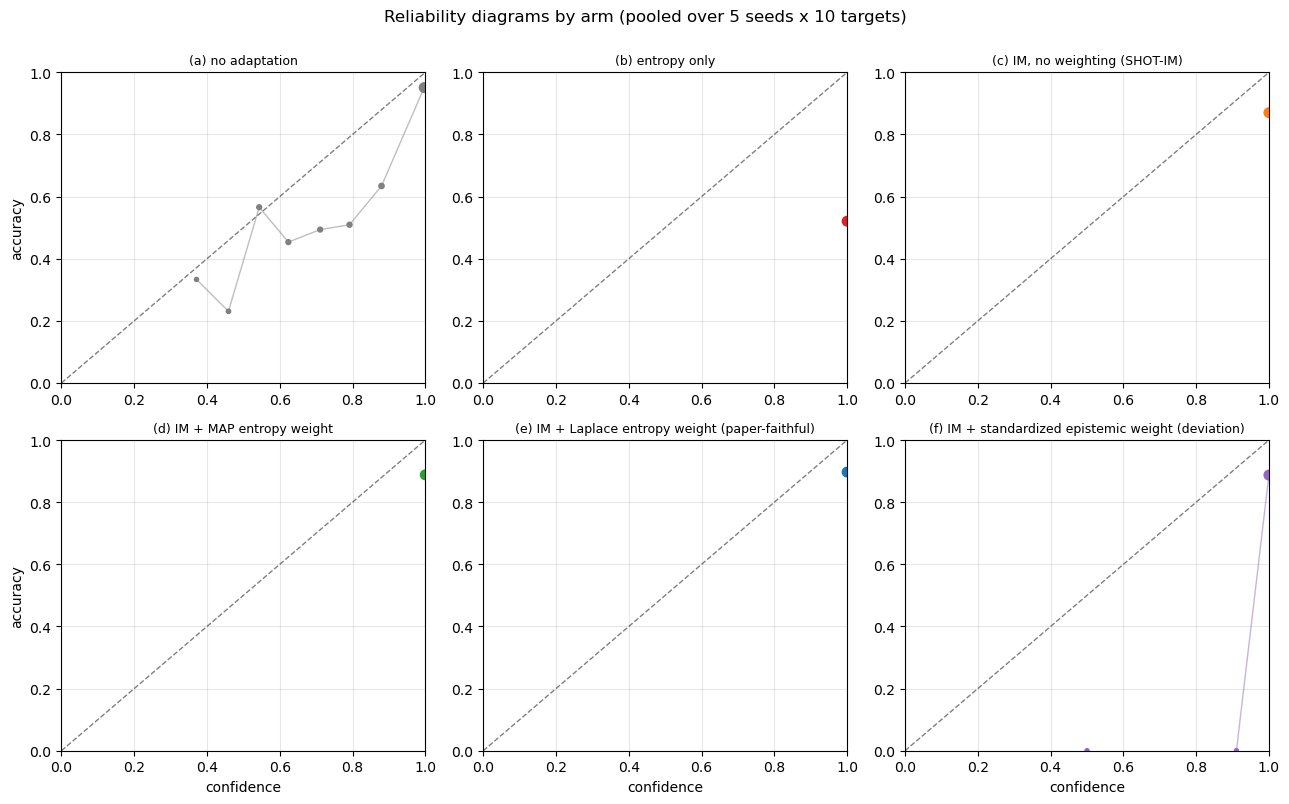

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for ax, arm in zip(axes, ARMS):
    probs = np.concatenate(pooled_probs[arm["key"]])
    y_np = np.concatenate(pooled_y[arm["key"]])
    bins = reliability_bins(probs, y_np, n_bins=12)
    sizes = 8 + 40 * np.sqrt(bins["bin_count"] / max(bins["bin_count"].max(), 1))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
    ax.plot(bins["bin_conf"], bins["bin_acc"], "-", color=ARM_COLORS[arm["key"]], alpha=0.5, linewidth=1)
    ax.scatter(bins["bin_conf"], bins["bin_acc"], s=sizes, color=ARM_COLORS[arm["key"]])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(arm["label"], fontsize=9)
    ax.grid(True, alpha=0.3)
for ax in axes[3:]:
    ax.set_xlabel("confidence")
for ax in [axes[0], axes[3]]:
    ax.set_ylabel("accuracy")

fig.suptitle("Reliability diagrams by arm (pooled over 5 seeds x 10 targets)", y=1.00)
fig.tight_layout()
plt.show()

## 6. Per-arm trajectories -- highest-shift subject

The IM loss, its two components, and the mean per-sample weight over the
300 adaptation steps, for the highest-shift target subject, mean ± std
band over 5 seeds. Arm (a) has no trajectory (no adaptation happens).

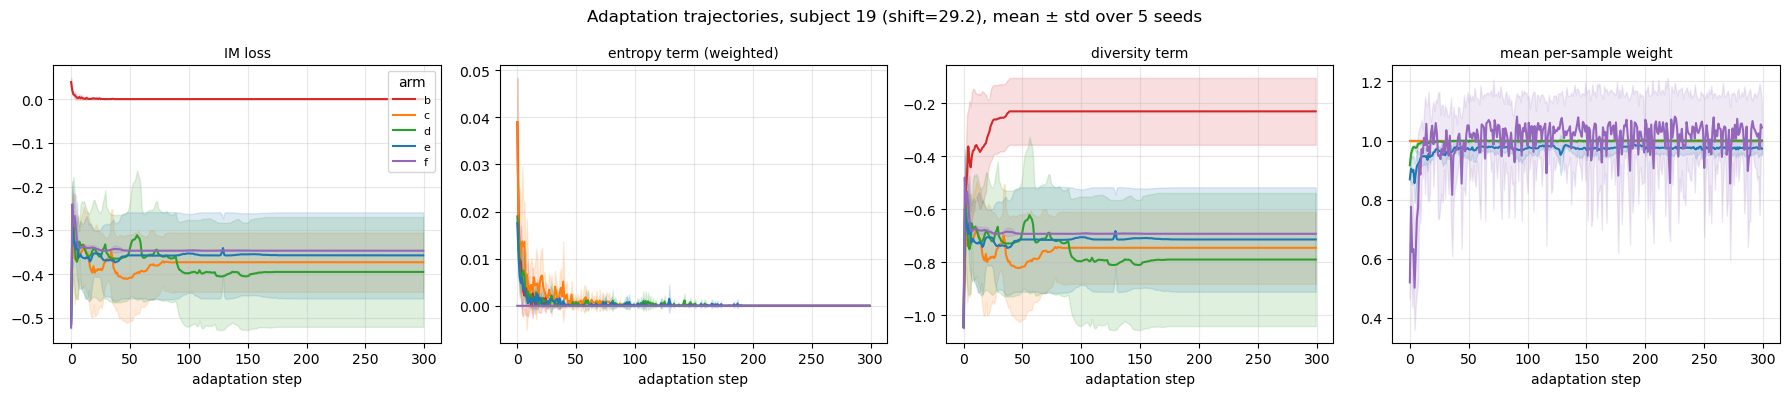

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fields = ["loss", "ent", "div", "mean_weight"]
titles = ["IM loss", "entropy term (weighted)", "diversity term", "mean per-sample weight"]

for arm in ARMS:
    if arm["weight_mode"] is None:
        continue
    per_seed = np.array([[trajectories[(seed, arm["key"])][field] for field in fields] for seed in SEEDS])
    # per_seed: (n_seeds, n_fields, n_steps)
    for ax, field, title, fi in zip(axes, fields, titles, range(len(fields))):
        vals = per_seed[:, fi, :]  # (n_seeds, n_steps)
        mean_v, std_v = vals.mean(axis=0), vals.std(axis=0)
        steps = np.arange(vals.shape[1])
        ax.plot(steps, mean_v, color=ARM_COLORS[arm["key"]], label=arm["key"])
        ax.fill_between(steps, mean_v - std_v, mean_v + std_v, color=ARM_COLORS[arm["key"]], alpha=0.15)

for ax, title in zip(axes, titles):
    ax.set_xlabel("adaptation step")
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8, title="arm")
fig.suptitle(f"Adaptation trajectories, subject {HIGH_SHIFT} (shift={shift_proxy[HIGH_SHIFT]:.1f}), mean ± std over 5 seeds")
fig.tight_layout()
plt.show()

## 7. Per-shift-tercile breakdown

Mean accuracy improvement over baseline ($\Delta$acc = acc$_{\text{arm}}$ -
acc$_{(a)}$, same seed/subject), grouped by shift tercile. The low and mid
terciles here (`27,15,21` and `7,30,11`) happen to be exactly the 6 subjects
already at >=94% baseline accuracy (§8) -- nothing to gain, only room to
drift. The high tercile (`22,20,8,19`) is the 4 genuinely hard subjects
(68-92% baseline). If uncertainty-guided weighting is doing what the paper
claims, arms (d)/(e) should turn positive specifically there, even while
every arm is negative on the easy majority.

         arm         low Δacc         mid Δacc        high Δacc
--------------------------------------------------------------
           a   0.0000+-0.0000   0.0000+-0.0000   0.0000+-0.0000
           b  -0.2374+-0.0522  -0.5100+-0.1220  -0.4429+-0.0279
           c  -0.0339+-0.0516  -0.1237+-0.1061  -0.0043+-0.0387
           d  -0.0178+-0.0233  -0.1302+-0.0374   0.0331+-0.1031
           e  -0.0164+-0.0225  -0.1325+-0.0400   0.0586+-0.1024
           f  -0.0043+-0.0048  -0.0809+-0.0576  -0.0306+-0.0656


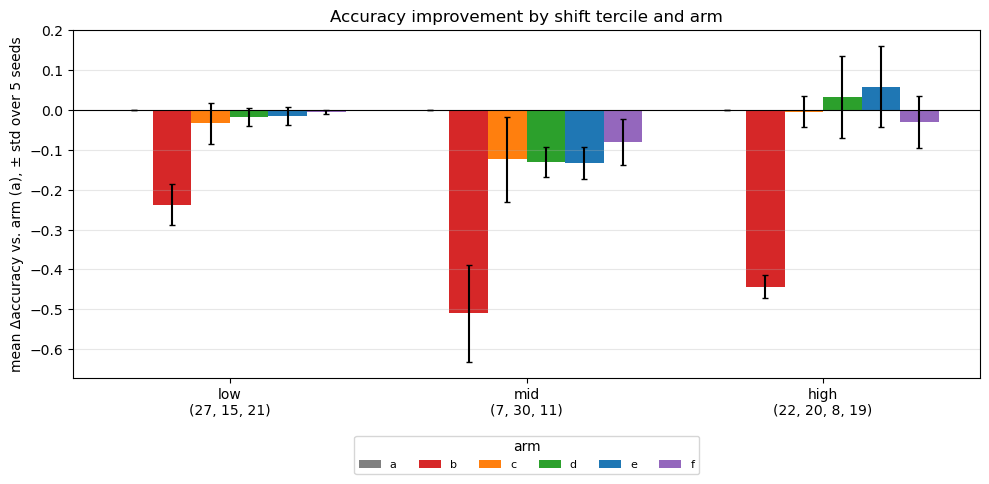

In [16]:
TERCILES = {"low": LOW_TERCILE, "mid": MID_TERCILE, "high": HIGH_TERCILE}

tercile_delta = {arm_key: {} for arm_key in ARM_KEYS}
for arm_key in ARM_KEYS:
    for tname, subs in TERCILES.items():
        per_seed_deltas = []
        for seed in SEEDS:
            baseline_acc = {r["subject"]: r["acc"] for r in by_seed_arm[(seed, "a")]}
            rows = [r for r in by_seed_arm[(seed, arm_key)] if r["subject"] in subs]
            per_seed_deltas.append(np.mean([r["acc"] - baseline_acc[r["subject"]] for r in rows]))
        tercile_delta[arm_key][tname] = (np.mean(per_seed_deltas), np.std(per_seed_deltas))

print(f"{'arm':>12s} {'low Δacc':>16s} {'mid Δacc':>16s} {'high Δacc':>16s}")
print("-" * 62)
for arm in ARMS:
    row = tercile_delta[arm["key"]]
    print(f"{arm['key']:>12s} " + " ".join(f"{row[t][0]:8.4f}+-{row[t][1]:.4f}" for t in ["low", "mid", "high"]))

fig, ax = plt.subplots(figsize=(10, 5))
tercile_names = ["low", "mid", "high"]
x = np.arange(len(tercile_names))
width = 0.13
for i, arm in enumerate(ARMS):
    means = [tercile_delta[arm["key"]][t][0] for t in tercile_names]
    stds = [tercile_delta[arm["key"]][t][1] for t in tercile_names]
    ax.bar(x + (i - 2.5) * width, means, width, yerr=stds, capsize=2,
           color=ARM_COLORS[arm["key"]], label=arm["key"])

ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n({', '.join(map(str, TERCILES[t]))})" for t in tercile_names])
ax.set_ylabel("mean Δaccuracy vs. arm (a), ± std over 5 seeds")
ax.set_title("Accuracy improvement by shift tercile and arm")
ax.legend(fontsize=8, title="arm", ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

(d) and (e) are the only arms that turn positive, and only on the high
tercile -- exactly the 4 subjects that actually needed adaptation. The mid
tercile is the *worst* hit for every adaptation arm, worse than low --
`7`/`30`/`11` sit at 94-99.5% baseline with presumably tighter, more
confidently-carved decision boundaries than `27`/`15`/`21` (all effectively
100%), so nudging the feature extractor at all costs them more. Arm (f)
stays negative even on the high tercile: standardizing against source
epistemic alone, without total entropy's aleatoric component, isn't enough
to reliably identify where adaptation should be trusted -- the deviation
underperforms the paper-faithful arm (e) exactly where it matters most.

## Summary

| item | result |
|---|---|
| IM loss | implemented in `src/im_adapt.py`, down-weighting restricted to $L_{\text{ent}}$ only |
| 6 arms | (b) collapses as expected (34% of runs, NLL ~13); (c) doesn't collapse but barely helps macro-average and hurts calibration; (d)/(e) are the only arms that ever beat baseline, and only on genuinely-shifted subjects, (e) best overall; (f) is a genuine deviation -- noisier weights, occasional partial collapse, stays negative even where (d)/(e) turn positive |
| shift-tercile breakdown | every arm looks worse than doing nothing when macro-averaged over all 10 targets; only (d)/(e) turn positive on the 4 genuinely-hard subjects (high tercile), while all arms lose ground on the 6 already-easy ones -- macro-averaging alone is misleading here |
| trajectories + reliability + multi-seed | logged for the highest-shift subject (§6); reliability compared across all 6 arms (§5); every headline number above is a 5-seed mean ± std (§4) |

This closes TODO.md's empirical core (§4-§9): the Laplace/BALD machinery is
numerically correct (§5), semantically sensible (§7), calibration-tested
(§8), and now shown to *do something useful* when actually used to guide
adaptation (§9) -- with an honest accounting of where the paper-faithful
weighting wins, where naive IM alone doesn't, and where the epistemic-only
deviation can misbehave. Next: §10 (open-set / HAPT) and §11 (report).